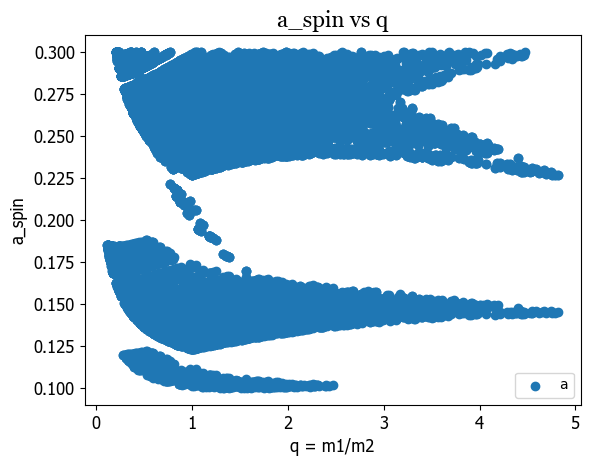

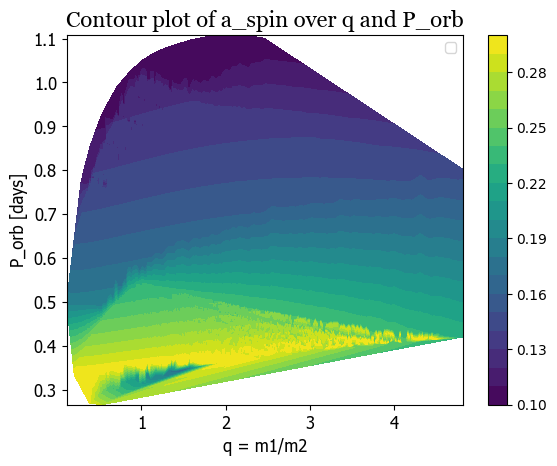

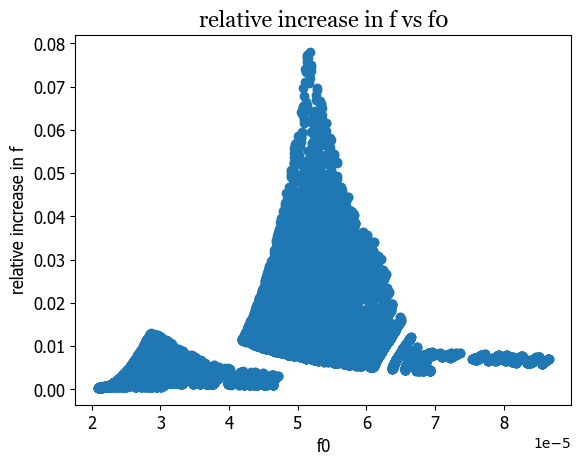

In [3]:
# get data in order first, then plot the ones dependent on time bc i need them to be in that specific row

# important libs and constants
import plot_utils as p
import numpy as np
import csv
G = 6.674e-11  # N*m^2/Kg^2
Msolar = 1.989e30  # kg
Rsolar = 6.957e8  # in m
c = 299792458.0  # m/s

# containers for all solutions (for combined plots)
all_q = []
all_a_spin = []
all_kQ = []
all_P_orb = []
all_f0 = []
all_f_final = []

with open("mid_spin_data.csv", "r") as o:
    reader = csv.DictReader(o)
    for row in reader:
        sol_id = row["ID"]

        data = np.load(f"mid_spin_sols/{sol_id}.npz")
        t = data["t"]
        f = data["f"]
        Omega = data["Omega"]

        # read metadata from csv
        m1 = float(row["m_WR/M_Sun"])
        m2 = float(row["m_companion/M_Sun"])
        a0 = float(row["initial separation a0 (m)"])
        Omega0 = float(row["initial spin Omega0 (Hz)"])
        f0 = float(row["initial frequency f0 (Hz)"])
        k = float(row["k"])
        Q = float(row["Q"])
        R1 = float(row["WR star Radius R_WR"])
        lifetime = float(row["lifetime (years)"])
        T_TF = float(row["tidal function timescale (years)"])
        T_GW = float(row["gw timescale (years)"])
        f_final = float(row["f_final (Hz)"])
        Omega_final = float(row["Omega_final (Hz)"])
        J = float(row["final angular momentum J (kg m^2/s)"])
        a_spin = float(row["spin parameter a_spin"])
        a_final = float(row["final separation a_final (m)"])
        a_min_si = float(row["minimum separation a_min (m)"])
        q = m1/m2

        all_q.append(q)
        all_a_spin.append(a_spin)
        all_kQ.append(k/Q)
        all_P_orb.append(2/f_final)
        all_f0.append(f0)
        all_f_final.append(f_final)

        
# combined plots for all solutions
q_array = np.array(all_q)
a_spin_array = np.array(all_a_spin)
kQ_array = np.array(all_kQ)
P_orb_array = np.array(all_P_orb)
f0_array = np.array(all_f0)
f_final_array = np.array(all_f_final)

# plot a_spin vs q
p.scatter2d(q_array, a_spin_array, xlabel='q = m1/m2',
            ylabel='a_spin', title=f"a_spin vs q", legend='a_spin(q)', colour=None, axis_font='Tahoma', axis_size=12, title_font='Georgia', title_size=16, legend_size=10)

# plot a_spin vs k/Q
# p.scatter2d(kQ_array, a_spin_array, xlabel='k/Q',
# ylabel='a_spin', title=f"a_spin vs k/Q for m1={format(m1/Msolar, '.0e')} M_sun, m2={format(m2/Msolar, '.0e')} M_sun, k={format(k, '.0e')}, Q={format(Q, '.0e')}, a0={format(a0, '.2e')} m, Ω0={format(Omega0, '.2e')} Hz, lifetime={format(lifetime, '.0e')} years, T_TF={format(T_TF, '.2e')} years, f0={format(f0, '.2e')} Hz, f_final={format(f_final, '.2e')} Hz, Omega_final={format(Omega_final, '.2e')} Hz", legend='a_spin(k/Q)', colour=None, axis_font='Tahoma', axis_size=12, title_font='Georgia', title_size=16, legend_size=10)

# plot q vs k/Q with a contour for a_spin
p.plot2d_contour(q_array, P_orb_array/(3600*24), a_spin_array, xlabel='q = m1/m2', ylabel='P_orb [days]',
                 title=f"Contour plot of a_spin over q and P_orb", legend='a_spin(q, k/Q)', axis_font='Tahoma', axis_size=12, title_font='Georgia', title_size=16, legend_size=10)

#f-f0/f0 vs f0 bc i'm thinking lower f0 might act increase more, is it relevant idk
p.scatter2d(f0_array,(f_final_array-f0_array)/f0_array, xlabel='f0',
            ylabel='relative increase in f', title=f"relative increase in f vs f0", colour=None, axis_font='Tahoma', axis_size=12, title_font='Georgia', title_size=16, legend_size=10)


In [ ]:
import random
import plot_utils as p
import numpy as np
import csv

with open("mid_spin_data.csv", "r") as o:
    rows = list(csv.DictReader(o))
    
    #for row in random.sample(rows, 100):
    for row in rows[0:1000]:

        sol_id = row["ID"]

        data = np.load(f"mid_spin_sols/{sol_id}.npz")
        t = data["t"]
        f = data["f"]
        Omega = data["Omega"]

        # read metadata from cjust oversv
        m1 = float(row["m_WR/M_Sun"])
        m2 = float(row["m_companion/M_Sun"])
        a0 = float(row["initial separation a0 (m)"])
        Omega0 = float(row["initial spin Omega0 (Hz)"])
        f0 = float(row["initial frequency f0 (Hz)"])
        k = float(row["k"])
        Q = float(row["Q"])
        R1 = float(row["WR star Radius R_WR"])
        lifetime = float(row["lifetime (years)"])
        T_TF = float(row["tidal function timescale (years)"])
        T_GW = float(row["gw timescale (years)"])
        f_final = float(row["f_final (Hz)"])
        Omega_final = float(row["Omega_final (Hz)"])
        J = float(row["final angular momentum J (kg m^2/s)"])
        a_spin = float(row["spin parameter a_spin"])
        a_final = float(row["final separation a_final (m)"])
        a_min_si = float(row["minimum separation a_min (m)"])
        q = m1/m2

        if (Q==1e4 and q>=1 and lifetime==100000):
            # plot f/f0(t)
            
            p.plot2d(t, f/f0, xlabel='t [years]',
                    ylabel='f/f0', title=f"f/f0 vs t for m1={format(m1, '.2e')} M_sun, m2={format(m2, '.2e')} M_sun, q={format(m1/m2, '.3')}, ID={format(sol_id)}", colour=None, axis_font='Tahoma', axis_size=12, title_font='Georgia', title_size=16, legend_size=10)
        
            # plot Omega(t)

            #p.plot2d(t, Omega, xlabel='t [years]',
            #         ylabel='Ω [Hz]', title=f"Ω vs t for m1={format(m1, '.2e')} M_sun, m2={format(m2, '.2e')} M_sun, q={format(m1/m2, '.3')}, ID={format(sol_id)}", colour=None, axis_font='Tahoma', axis_size=12, title_font='Georgia', title_size=16, legend_size=10)
        



In [ ]:
import plot_utils as p
import numpy as np
import csv

all_a_spin = []
all_m1 = []
all_q = []

with open("mid_spin_data.csv", "r") as o:
    rows = list(csv.DictReader(o))

    for row in rows:

        sol_id = row["ID"]

        data = np.load(f"mid_spin_sols/{sol_id}.npz")
        t = data["t"]
        f = data["f"]
        Omega = data["Omega"]

        m1 = float(row["m_WR/M_Sun"])
        m2 = float(row["m_companion/M_Sun"])
        a0 = float(row["initial separation a0 (m)"])
        Omega0 = float(row["initial spin Omega0 (Hz)"])
        f0 = float(row["initial frequency f0 (Hz)"])
        k = float(row["k"])
        Q = float(row["Q"])
        R1 = float(row["WR star Radius R_WR"])
        lifetime = float(row["lifetime (years)"])
        T_TF = float(row["tidal function timescale (years)"])
        T_GW = float(row["gw timescale (years)"])
        f_final = float(row["f_final (Hz)"])
        Omega_final = float(row["Omega_final (Hz)"])
        J = float(row["final angular momentum J (kg m^2/s)"])
        a_spin = float(row["spin parameter a_spin"])
        a_final = float(row["final separation a_final (m)"])
        a_min_si = float(row["minimum separation a_min (m)"])
        q = m1/m2

        all_a_spin.append(a_spin)
        all_m1.append(m1)
        all_q.append(q)

a_spin_array = np.array(all_a_spin)
m1_array = np.array(all_m1)
q_array = np.array(all_q)

# plot a_spin/m1
p.scatter2d(m1_array, a_spin_array, xlabel='m1', ylabel='a_spin', 
    title=f"a_spin vs m1", legend='a_spin(m1)', colour=None, axis_font="tahoma", axis_size=12, title_font="georgia", title_size=16, legend_size=10)
        
# plot m1 vs q with a contour for a_spin
p.plot2d_contour(q_array, m1_array, a_spin_array, xlabel='q = m1/m2', ylabel='m1',
                 title=f"Contour plot of a_spin over q and m1", legend='a_spin(q, k/Q)', axis_font="tahoma", axis_size=12, title_font="georgia", title_size=16, legend_size=10)
   